In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd

df_news_final_project = pd.read_parquet(
    "/content/drive/MyDrive/NLP_AI_Impact_Project/data/entities_extracted.parquet"
)

print(df_news_final_project.shape)

(188910, 13)


In [57]:
df_news_final_project.head(5)

,url,date,language,title,text,word_count,clean_text,processed_text,topic,industry,companies,companies_clean,technologies
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",483,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",bad idea ai price bad market cap price today c...,1,Other,"[Bad Idea AI Price, Price Today &]",[],[]
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,812,\n\nThis AI video of gymnastics might be the f...,this ai video of gymnastics might be the frea...,11,Other,[MENU],[],[]
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",884,"\n\nIf using AI feels like a chore, try this -...",if using ai feels like a chore try this boing...,11,Other,"[AI, MENU]",[],[]
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,596,The Road Ahead: How China's AI Foundation M...,the road ahead how china s ai foundation mode...,10,Transportation,[AI Foundation Model is Shaping the Future of ...,[],"[Deep Learning, Cloud Computing]"
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,622,Microsoft and Nvidia to Empower Developers ...,microsoft and nvidia to empower developers wi...,10,Tech Platforms,"[Microsoft, өтуСенбі, Microsoft, Microsoft, AI...","[Post, Microsoft, GeForce, Windows, Hugging Fa...","[LLaMA, Large Language Model]"


In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clovisdalmolinvieira/news-sentiment-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/news-sentiment-analysis


In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clovisdalmolinvieira/news-sentiment-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/news-sentiment-analysis


In [60]:
import pandas as pd
import os

file_name = os.listdir(path)[0]
file_path = os.path.join(path, file_name)

df_sentiment = pd.read_csv(file_path)

print(df_sentiment.shape)

(3500, 8)


In [61]:
print(df_sentiment.columns)
print(df_sentiment.head())
print(df_sentiment["Sentiment"].value_counts())

Index(['Source', 'Author', 'Title', 'Description', 'URL', 'Published At',
       'Sentiment', 'Type'],
      dtype='object')
          Source          Author  \
0        stgnews  Bridger Palmer   
1  Zimbabwe Mail  Staff Reporter   
2      4-traders             NaN   
3      4-traders             NaN   
4         PLANET             NaN   

                                               Title  \
0  Pine View High teacher wins Best in State awar...   
1  Businesses Face Financial Strain Amid Liquidit...   
2  Musk donates to super pac working to elect Tru...   
3  US FTC issues warning to franchisors over unfa...   
4                          Rooftop solar's dark side   

                                         Description  \
0  ST. GEORGE — Kaitlyn Larson, a first-year teac...   
1  Harare, Zimbabwe – Local businesses are grappl...   
2  (marketscreener.com) Billionaire Elon Musk has...   
3  (marketscreener.com) A U.S. trade regulator on...   
4  4.5 million households in the U.S. hav

In [62]:
print(df_sentiment.isnull().sum())

Source            0
Author          988
Title             0
Description       0
URL               0
Published At      0
Sentiment         0
Type              0
dtype: int64


In [63]:
df_sentiment["text"] = (
    df_sentiment["Title"] + " " + df_sentiment["Description"]
)

df_sentiment = df_sentiment[["text", "Sentiment"]]
df_sentiment = df_sentiment.dropna()

print(df_sentiment.shape)

(3500, 2)


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_sentiment["text"],
    df_sentiment["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df_sentiment["Sentiment"]
)

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [67]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.76      0.70      0.73       115
     neutral       0.81      0.81      0.81       158
    positive       0.88      0.89      0.89       427

    accuracy                           0.84       700
   macro avg       0.82      0.80      0.81       700
weighted avg       0.84      0.84      0.84       700



In [68]:
X_news = vectorizer.transform(df_news_final_project["clean_text"])

df_news_final_project["sentiment"] = model.predict(X_news)

probs = model.predict_proba(X_news)
df_news_final_project["sentiment_score"] = probs.max(axis=1)

df_news_final_project["sentiment_numeric"] = df_news_final_project["sentiment"].map({
    "negative": -1,
    "neutral": 0,
    "positive": 1
})

In [69]:
df_news_final_project["sentiment"].value_counts(normalize=True)

,proportion
sentiment,
positive,0.860304
negative,0.116860
neutral,0.022836


In [70]:
df_news_final_project.groupby("topic")["sentiment"].value_counts(normalize=True)

topic  sentiment
0      positive     0.849929
       neutral      0.099953
       negative     0.050118
1      positive     0.989358
       negative     0.005493
       neutral      0.005149
2      positive     0.970658
       negative     0.017274
       neutral      0.012068
3      positive     0.835078
       negative     0.145621
       neutral      0.019301
4      positive     0.803775
       negative     0.172088
       neutral      0.024138
5      positive     0.915778
       negative     0.074399
       neutral      0.009822
6      positive     0.913374
       negative     0.077103
       neutral      0.009523
7      positive     0.996113
       neutral      0.002430
       negative     0.001458
8      positive     0.887282
       negative     0.082494
       neutral      0.030224
9      positive     0.852736
       negative     0.138242
       neutral      0.009022
10     positive     0.856568
       negative     0.125825
       neutral      0.017607
11     positive     0.902231
       neutral      0.051049
       negative     0.046721
Name: proportion, dtype: float64

In [71]:
df_news_final_project.groupby("industry")["sentiment_numeric"].mean().sort_values()

,sentiment_numeric
industry,
Healthcare,0.562650
Government,0.603069
Manufacturing,0.629974
Legal,0.683412
Retail,0.701116
Other,0.709125
Education,0.724536
Insurance,0.772487
Media & Entertainment,0.787192


In [72]:
df_entities = (
    df_news_final_project
    .explode("companies_clean")
    .dropna(subset=["companies_clean"])
)

company_counts = df_entities["companies_clean"].value_counts()

top_n = 15
top_companies = company_counts.head(top_n).index

entity_sentiment = (
    df_entities
    .groupby("companies_clean")["sentiment_numeric"]
    .mean()
)

entity_distribution = (
    df_entities
    .groupby("companies_clean")["sentiment"]
    .value_counts(normalize=True)
    .unstack()
)

entity_summary = pd.DataFrame({
    "mentions": company_counts,
    "avg_sentiment": entity_sentiment
}).join(entity_distribution)

entity_summary = entity_summary.loc[top_companies]

entity_summary = entity_summary.sort_values("mentions", ascending=False)

entity_summary

,mentions,avg_sentiment,negative,neutral,positive
companies_clean,,,,,
Microsoft,16125,0.781271,0.105426,0.007876,0.886698
Google,15350,0.704039,0.145472,0.005016,0.849511
Apple,7674,0.845452,0.074537,0.005473,0.919990
Amazon,6426,0.804388,0.095549,0.004513,0.899938
Meta,4870,0.743532,0.125257,0.005955,0.868789
Android,4009,0.815914,0.091544,0.000998,0.907458
WhatsApp,3989,0.799198,0.098521,0.003760,0.897719
Intel,2988,0.854083,0.069612,0.006693,0.923695
Samsung,2937,0.919305,0.039156,0.002383,0.958461


In [73]:
df_tech = (
    df_news_final_project
    .explode("technologies")
    .dropna(subset=["technologies"])
)

tech_counts = df_tech["technologies"].value_counts()

top_n = 20
top_tech = tech_counts.head(top_n).index

tech_sentiment = (
    df_tech
    .groupby("technologies")["sentiment_numeric"]
    .mean()
)

tech_distribution = (
    df_tech
    .groupby("technologies")["sentiment"]
    .value_counts(normalize=True)
    .unstack()
)

tech_summary = pd.DataFrame({
    "mentions": tech_counts,
    "avg_sentiment": tech_sentiment
}).join(tech_distribution)

tech_summary = tech_summary.loc[top_tech]
tech_summary = tech_summary.sort_values("mentions", ascending=False)

tech_summary

,mentions,avg_sentiment,negative,neutral,positive
technologies,,,,,
ERP,36660,0.807065,0.089471,0.013993,0.896536
ChatGPT,29951,0.789957,0.101366,0.007312,0.891322
Generative AI,19971,0.764458,0.114015,0.007511,0.878474
SAP,18160,0.757324,0.117291,0.008095,0.874615
Blockchain,13791,0.860271,0.066130,0.007469,0.926401
Machine Learning,13762,0.696701,0.145618,0.012062,0.842319
Cybersecurity,9360,0.667628,0.161752,0.008868,0.829380
Cloud Computing,7957,0.838004,0.080432,0.001131,0.918437
Semiconductor,7764,0.904302,0.044565,0.006569,0.948867


In [74]:
df_news_final_project.groupby("industry")["sentiment"].value_counts(normalize=True)

industry               sentiment
Education              positive     0.851833
                       negative     0.127297
                       neutral      0.020871
Energy                 positive     0.893928
                       negative     0.089978
                       neutral      0.016094
Finance                positive     0.879827
                       negative     0.082897
                       neutral      0.037276
Government             positive     0.797414
                       negative     0.194346
                       neutral      0.008240
Healthcare             positive     0.763920
                       negative     0.201270
                       neutral      0.034810
Insurance              positive     0.883598
                       negative     0.111111
                       neutral      0.005291
Legal                  positive     0.836917
                       negative     0.153505
                       neutral      0.009578
Manufacturing          positive     0.805504
                       negative     0.175530
                       neutral      0.018966
Media & Entertainment  positive     0.884458
                       negative     0.097266
                       neutral      0.018276
Other                  positive     0.842552
                       negative     0.133427
                       neutral      0.024021
Real Estate            positive     0.905864
                       negative     0.078704
                       neutral      0.015432
Retail                 positive     0.843518
                       negative     0.142402
                       neutral      0.014081
Tech Platforms         positive     0.900142
                       negative     0.074709
                       neutral      0.025149
Telecommunications     positive     0.938667
                       negative     0.058667
                       neutral      0.002667
Transportation         positive     0.961961
                       negative     0.034741
                       neutral      0.003298
Name: proportion, dtype: float64

In [75]:
industry_sent = (
    df_news_final_project
    .groupby("industry")["sentiment_numeric"]
    .mean()
    .sort_values()
)

industry_sent

,sentiment_numeric
industry,
Healthcare,0.562650
Government,0.603069
Manufacturing,0.629974
Legal,0.683412
Retail,0.701116
Other,0.709125
Education,0.724536
Insurance,0.772487
Media & Entertainment,0.787192


In [76]:
df_news_final_project.explode("companies_clean") \
    .groupby("companies_clean")["sentiment"].value_counts(normalize=True)

companies_clean                                   sentiment
3D Printing                                       positive     0.750000
                                                  negative     0.250000
5th QuarterSportsniteeSportsStats PredictionsHow  positive     0.946667
                                                  negative     0.053333
AGARWALOptions Trading Advice                     positive     0.970760
                                                                 ...   
treasury                                          neutral      0.007812
user                                              positive     0.778302
                                                  neutral      0.216981
                                                  negative     0.004717
windowME TVAbout Laff                             positive     1.000000
Name: proportion, Length: 3003, dtype: float64

In [77]:
df_news_final_project["date"] = pd.to_datetime(df_news_final_project["date"])
df_news_final_project["year_month"] = df_news_final_project["date"].dt.to_period("M")

df_news_final_project.groupby("year_month")["sentiment"].value_counts(normalize=True)

year_month  sentiment
2022-01     positive     0.812165
            negative     0.160107
            neutral      0.027728
2022-02     positive     0.773017
            negative     0.208751
                           ...   
2026-01     negative     0.081239
            neutral      0.060144
2026-02     positive     0.881096
            negative     0.070140
            neutral      0.048764
Name: proportion, Length: 150, dtype: float64

In [78]:
df_it = (
    df_news_final_project
    .explode("technologies")
    .dropna(subset=["technologies"])
)

industry_tech_sent = (
    df_it
    .groupby(["industry", "technologies"])
    .agg(
        avg_sentiment=("sentiment_numeric", "mean"),
        mention_count=("sentiment_numeric", "size")
    )
    .reset_index()
)
industry_tech_sent = industry_tech_sent[
    industry_tech_sent["mention_count"] > 200
]

industry_tech_sent = industry_tech_sent.sort_values(
    ["industry", "avg_sentiment"],
    ascending=[True, False]
)

print("=== Industry × Technology Sentiment ===")
display(industry_tech_sent.head(20))



df_entities = (
    df_news_final_project
    .explode("companies_clean")
    .dropna(subset=["companies_clean"])
)

company_counts = df_entities["companies_clean"].value_counts()

top15_companies = company_counts.head(15).index

df_top_companies = df_entities[
    df_entities["companies_clean"].isin(top15_companies)
]

df_ct = (
    df_top_companies
    .explode("technologies")
    .dropna(subset=["technologies"])
)

company_tech_sent = (
    df_ct
    .groupby(["companies_clean", "technologies"])
    .agg(
        avg_sentiment=("sentiment_numeric", "mean"),
        mention_count=("sentiment_numeric", "size")
    )
    .reset_index()
)

company_tech_sent = company_tech_sent[
    company_tech_sent["mention_count"] > 200
]

company_tech_sent = company_tech_sent.sort_values(
    ["companies_clean", "avg_sentiment"],
    ascending=[True, False]
)

print("=== Company (Top 15) × Technology Sentiment ===")
display(company_tech_sent.head(30))

=== Industry × Technology Sentiment ===


,industry,technologies,avg_sentiment,mention_count
7,Education,Claude,0.816901,213
6,Education,ChatGPT,0.799820,3337
27,Education,Large Language Model,0.798371,491
19,Education,GPT-4,0.786127,346
20,Education,Gemini,0.778116,329
15,Education,ERP,0.764441,2666
21,Education,Generative AI,0.757305,1677
14,Education,Deep Learning,0.753943,317
9,Education,Computer Vision,0.726908,249
31,Education,Neural Network,0.721739,230


=== Company (Top 15) × Technology Sentiment ===


,companies_clean,technologies,avg_sentiment,mention_count
5,Amazon,CRM,0.938983,295
11,Amazon,Copilot,0.917603,534
44,Amazon,Semiconductor,0.903553,394
23,Amazon,Gemini,0.875000,616
14,Amazon,Data Center,0.870270,740
3,Amazon,Blockchain,0.868580,662
13,Amazon,Cybersecurity,0.866048,754
22,Amazon,GPT-4,0.839237,367
16,Amazon,ERP,0.832759,2320
42,Amazon,SAP,0.829841,1575


In [79]:
most_negative_it = industry_tech_sent.sort_values(
    "avg_sentiment"
).head(10)

print("=== Most Negative Industry × Technology ===")
display(most_negative_it)

=== Most Negative Industry × Technology ===


,industry,technologies,avg_sentiment,mention_count
158,Government,Cloud Computing,-0.280822,292
163,Government,Data Center,0.016949,295
228,Healthcare,Natural Language Processing,0.098143,377
229,Healthcare,Neural Network,0.231660,259
206,Healthcare,Computer Vision,0.290657,289
525,Tech Platforms,Enterprise Resource Planning,0.353125,320
162,Government,Cybersecurity,0.354935,1003
235,Healthcare,Robotics,0.377419,620
336,Manufacturing,Robotics,0.424558,961
211,Healthcare,Deep Learning,0.439394,462


In [80]:
most_positive_it = industry_tech_sent.sort_values(
    "avg_sentiment",
    ascending=False
).head(10)

print("=== Most Positive Industry × Technology ===")
display(most_positive_it)

=== Most Positive Industry × Technology ===


,industry,technologies,avg_sentiment,mention_count
389,Media & Entertainment,Semiconductor,0.986849,3954
355,Media & Entertainment,Cloud Computing,0.986663,4049
146,Finance,Trading Platform,0.978270,2301
350,Media & Entertainment,Blockchain,0.973753,4229
555,Tech Platforms,Supply Chain Management,0.957447,470
144,Finance,Stable Diffusion,0.942029,207
351,Media & Entertainment,CRM,0.931900,558
515,Tech Platforms,Claude,0.930579,605
513,Tech Platforms,Canva,0.929630,270
357,Media & Entertainment,Copilot,0.917603,801


In [81]:
most_negative_ct = (
    company_tech_sent
    .sort_values(["companies_clean", "avg_sentiment"])
    .groupby("companies_clean")
    .head(1)
)

print("=== Most Negative Technology per Top Company ===")
display(most_negative_ct)

=== Most Negative Technology per Top Company ===


,companies_clean,technologies,avg_sentiment,mention_count
15,Amazon,Deep Learning,0.693727,271
70,Android,Enterprise Resource Planning,0.315068,292
113,Apple,Computer Vision,0.459459,259
160,Ethereum,ChatGPT,0.917910,268
234,Google,Neural Network,0.603416,527
281,Instagram,Machine Learning,0.810945,201
335,Intel,Oracle,0.722488,209
372,Meta,GPT-4,0.689655,377
410,Microsoft,Computer Vision,0.406619,423
473,Nvidia,Generative AI,0.892340,483


In [101]:
most_positive_ct = (
    company_tech_sent
    .sort_values(["companies_clean", "avg_sentiment"], ascending=[True, False])
    .groupby("companies_clean")
    .head(1)
)

print("=== Most Positive Technology per Top Company ===")
display(most_positive_ct)

=== Most Positive Technology per Top Company ===


,companies_clean,technologies,avg_sentiment,mention_count
5,Amazon,CRM,0.938983,295
74,Android,GPT-4,0.963158,380
111,Apple,Claude,0.929155,367
197,Ethereum,Trading Platform,0.997374,1523
249,Google,Trading Platform,0.923636,275
273,Instagram,Gemini,0.916168,334
311,Intel,Copilot,0.939815,432
355,Meta,Blockchain,0.847545,387
411,Microsoft,Copilot,0.867755,2450
455,Nvidia,Blockchain,0.979592,294


In [83]:
industry_variance = (
    df_it
    .groupby(["industry", "technologies"])
    .agg(
        sentiment_std=("sentiment_numeric", "std"),
        mention_count=("sentiment_numeric", "size")
    )
    .reset_index()
)

industry_variance = industry_variance[
    industry_variance["mention_count"] > 100
]

industry_variance = industry_variance.sort_values(
    "sentiment_std",
    ascending=False
)

industry_variance.head(20)

,industry,technologies,sentiment_std,mention_count
163,Government,Data Center,0.998153,295
228,Healthcare,Natural Language Processing,0.985761,377
229,Healthcare,Neural Network,0.968697,259
158,Government,Cloud Computing,0.961408,292
198,Healthcare,Autonomous Vehicle,0.954930,168
180,Government,Natural Language Processing,0.953578,108
206,Healthcare,Computer Vision,0.945723,289
525,Tech Platforms,Enterprise Resource Planning,0.935367,320
311,Manufacturing,Computer Vision,0.933788,147
162,Government,Cybersecurity,0.933755,1003


In [84]:
impact_table = (
    df_it
    .groupby(["industry", "technologies"])
    .agg(
        avg_sentiment=("sentiment_numeric", "mean"),
        sentiment_std=("sentiment_numeric", "std"),
        mention_count=("sentiment_numeric", "size")
    )
    .reset_index()
)

impact_table = impact_table[
    impact_table["mention_count"] > 100
]

def classify_impact(row):
    mean = row["avg_sentiment"]
    std = row["sentiment_std"]

    if std >= 0.9:
        return "Polarized"

    if mean > 0.4 and std < 0.7:
        return "Positive"

    if mean < -0.2 and std < 0.7:
        return "Negative"

    return "Mixed"


impact_table["impact_type"] = impact_table.apply(classify_impact, axis=1)

impact_table = impact_table.sort_values(
    ["industry", "avg_sentiment"],
    ascending=[True, False]
)

impact_table.head(30)
impact_table = (
    df_it
    .groupby(["industry", "technologies"])
    .agg(
        avg_sentiment=("sentiment_numeric", "mean"),
        sentiment_std=("sentiment_numeric", "std"),
        mention_count=("sentiment_numeric", "size")
    )
    .reset_index()
)

impact_table = impact_table[
    impact_table["mention_count"] > 100
]

def classify_impact(row):
    mean = row["avg_sentiment"]
    std = row["sentiment_std"]

    if std >= 0.9:
        return "Polarized"

    if mean > 0.4 and std < 0.7:
        return "Positive"

    if mean < -0.2 and std < 0.7:
        return "Negative"

    return "Mixed"


impact_table["impact_type"] = impact_table.apply(classify_impact, axis=1)

impact_table = impact_table.sort_values(
    ["industry", "avg_sentiment"],
    ascending=[True, False]
)

impact_table.head(30)

,industry,technologies,avg_sentiment,sentiment_std,mention_count,impact_type
39,Education,Salesforce,0.884848,0.433450,165,Positive
40,Education,Semiconductor,0.839286,0.529381,112,Positive
5,Education,Canva,0.825243,0.549994,103,Positive
7,Education,Claude,0.816901,0.574042,213,Positive
6,Education,ChatGPT,0.799820,0.595315,3337,Positive
27,Education,Large Language Model,0.798371,0.601085,491,Positive
19,Education,GPT-4,0.786127,0.614259,346,Positive
10,Education,Copilot,0.782123,0.620361,179,Positive
20,Education,Gemini,0.778116,0.621766,329,Positive
15,Education,ERP,0.764441,0.628906,2666,Positive


In [85]:
impact_summary = (
    impact_table
    .groupby("industry")["impact_type"]
    .value_counts()
    .unstack(fill_value=0)
)

impact_summary

impact_type,Mixed,Polarized,Positive
industry,,,
Education,5,0,19
Energy,2,0,13
Finance,4,0,32
Government,11,7,1
Healthcare,15,5,4
Legal,18,0,7
Manufacturing,8,1,1
Media & Entertainment,3,0,29
Other,2,0,10


In [86]:
df_news_final_project["date"] = pd.to_datetime(
    df_news_final_project["date"],
    errors="coerce"
)

df_news_final_project["year_month"] = (
    df_news_final_project["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

sentiment_over_time = (
    df_news_final_project
    .groupby("year_month")["sentiment_numeric"]
    .mean()
    .reset_index()
)

sentiment_over_time.head()

,year_month,sentiment_numeric
0,2022-01-01,0.652057
1,2022-02-01,0.564266
2,2022-03-01,0.631919
3,2022-04-01,0.625828
4,2022-05-01,0.613652


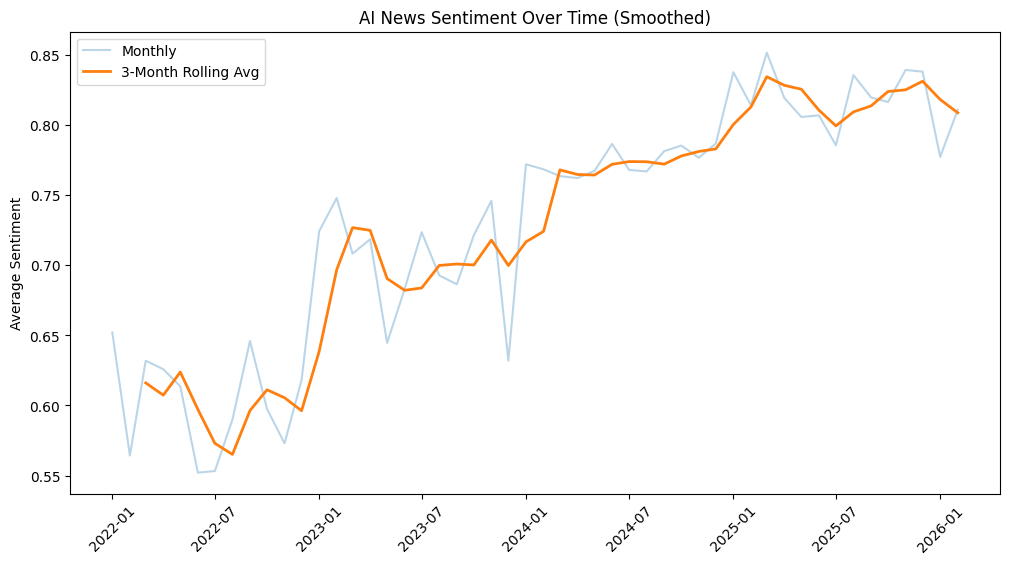

In [87]:
import matplotlib.pyplot as plt

sentiment_over_time = sentiment_over_time.sort_values("year_month")

sentiment_over_time["rolling_3m"] = (
    sentiment_over_time["sentiment_numeric"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    sentiment_over_time["year_month"],
    sentiment_over_time["sentiment_numeric"],
    alpha=0.3,
    label="Monthly"
)

plt.plot(
    sentiment_over_time["year_month"],
    sentiment_over_time["rolling_3m"],
    linewidth=2,
    label="3-Month Rolling Avg"
)

plt.xticks(rotation=45)
plt.legend()
plt.title("AI News Sentiment Over Time (Smoothed)")
plt.ylabel("Average Sentiment")
plt.show()

In [88]:
industry_time = (
    df_news_final_project
    .groupby(["year_month", "industry"])["sentiment_numeric"]
    .mean()
    .reset_index()
)

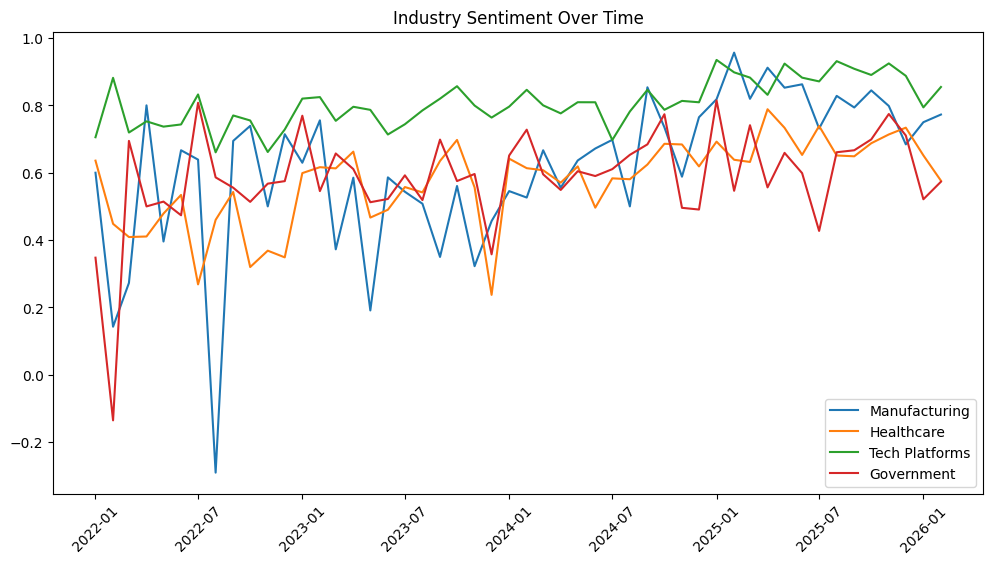

In [89]:
top_industries = ["Manufacturing", "Healthcare", "Tech Platforms", "Government"]

plt.figure(figsize=(12,6))

for ind in top_industries:
    subset = industry_time[industry_time["industry"] == ind]
    plt.plot(subset["year_month"], subset["sentiment_numeric"], label=ind)

plt.xticks(rotation=45)
plt.legend()
plt.title("Industry Sentiment Over Time")
plt.show()

In [90]:
df_tech_time = (
    df_news_final_project
    .explode("technologies")
    .dropna(subset=["technologies"])
)

tech_time = (
    df_tech_time
    .groupby(["year_month", "technologies"])["sentiment_numeric"]
    .mean()
    .reset_index()
)

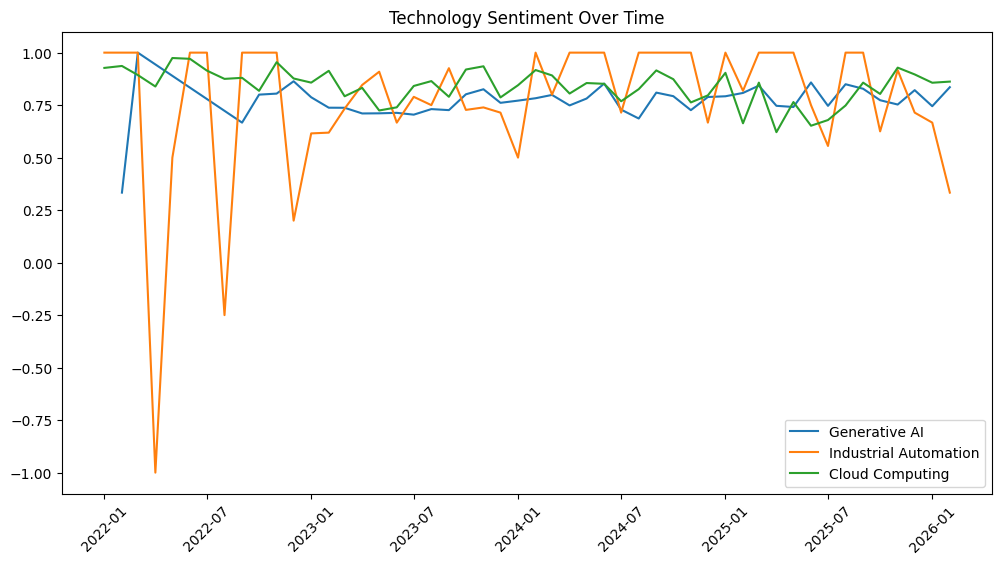

In [91]:
key_tech = ["Generative AI", "Industrial Automation", "Cloud Computing"]

plt.figure(figsize=(12,6))

for tech in key_tech:
    subset = tech_time[tech_time["technologies"] == tech]
    plt.plot(subset["year_month"], subset["sentiment_numeric"], label=tech)

plt.xticks(rotation=45)
plt.legend()
plt.title("Technology Sentiment Over Time")
plt.show()

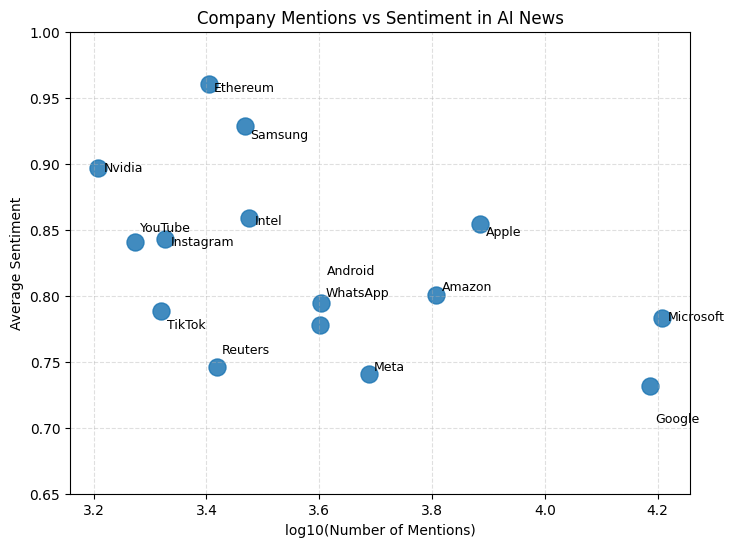

In [104]:
entity_summary["log_mentions"] = np.log10(entity_summary["mentions"])
y_jitter = entity_summary["avg_sentiment"] + np.random.normal(0, 0.01, len(entity_summary))

plt.figure(figsize=(8,6))

plt.scatter(
    entity_summary["log_mentions"],
    y_jitter,
    s=150,
    alpha=0.85
)

for company, row in entity_summary.iterrows():
    plt.text(
        row["log_mentions"] + 0.01,
        row["avg_sentiment"],
        company,
        fontsize=9
    )

plt.xlabel("log10(Number of Mentions)")
plt.ylabel("Average Sentiment")
plt.title("Company Mentions vs Sentiment in AI News")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0.65, 1.0)
plt.show()

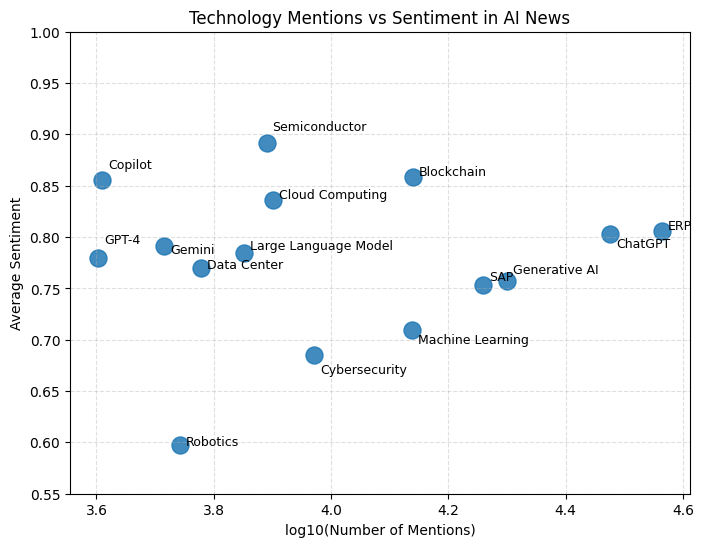

In [107]:
df_tech = (
    df_news_final_project
    .explode("technologies")
    .dropna(subset=["technologies"])
)
tech_counts = df_tech["technologies"].value_counts()
top_n = 15
top_tech = tech_counts.head(top_n).index
tech_sentiment = (
    df_tech
    .groupby("technologies")["sentiment_numeric"]
    .mean()
)

tech_summary = pd.DataFrame({
    "mentions": tech_counts,
    "avg_sentiment": tech_sentiment
})
tech_summary = tech_summary.loc[top_tech]
tech_summary = tech_summary.sort_values("mentions", ascending=False)
tech_summary["log_mentions"] = np.log10(tech_summary["mentions"])
y_jitter = tech_summary["avg_sentiment"] + np.random.normal(0, 0.01, len(tech_summary))
plt.figure(figsize=(8,6))
plt.scatter(
    tech_summary["log_mentions"],
    y_jitter,
    s=150,
    alpha=0.85
)
for tech, row in tech_summary.iterrows():
    plt.text(
        row["log_mentions"] + 0.01,
        row["avg_sentiment"],
        tech,
        fontsize=9
    )

plt.xlabel("log10(Number of Mentions)")
plt.ylabel("Average Sentiment")
plt.title("Technology Mentions vs Sentiment in AI News")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0.55, 1.0)
plt.show()

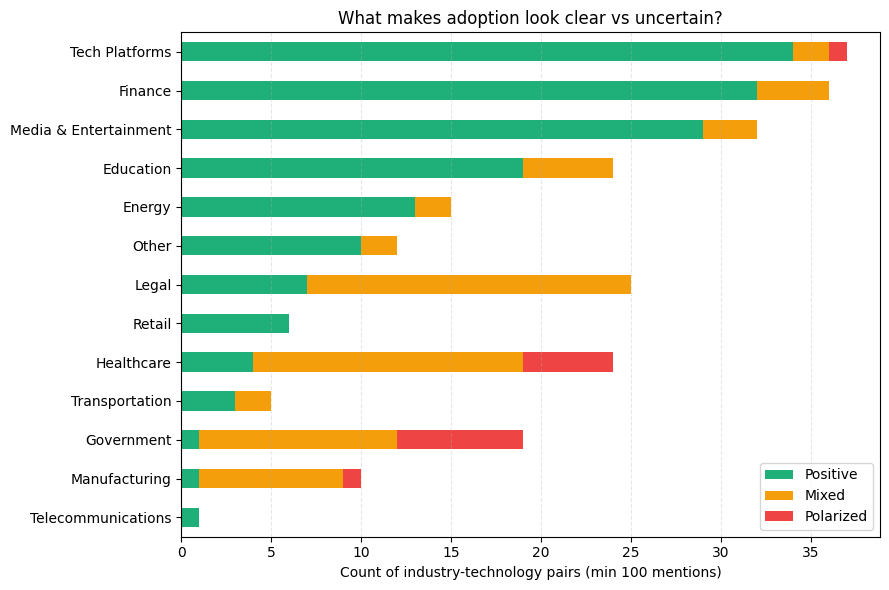

In [112]:
import matplotlib.pyplot as plt

df_plot = impact_table.copy()

df_plot = df_plot[df_plot["mention_count"] > 100]

industry_counts = (
    df_plot
    .groupby(["industry","impact_type"])
    .size()
    .unstack(fill_value=0)
)

industry_counts = industry_counts[["Positive","Mixed","Polarized"]]

industry_counts = industry_counts.sort_values(
    by="Positive",
    ascending=False
)

colors = {
    "Positive": "#1fb07a",
    "Mixed": "#f59e0b",
    "Polarized": "#ef4444"
}

industry_counts.plot(
    kind="barh",
    stacked=True,
    color=[colors[c] for c in industry_counts.columns],
    figsize=(9,6)
)

plt.xlabel("Count of industry-technology pairs (min 100 mentions)")
plt.ylabel("")
plt.title("What makes adoption look clear vs uncertain?")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.legend(loc="lower right")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

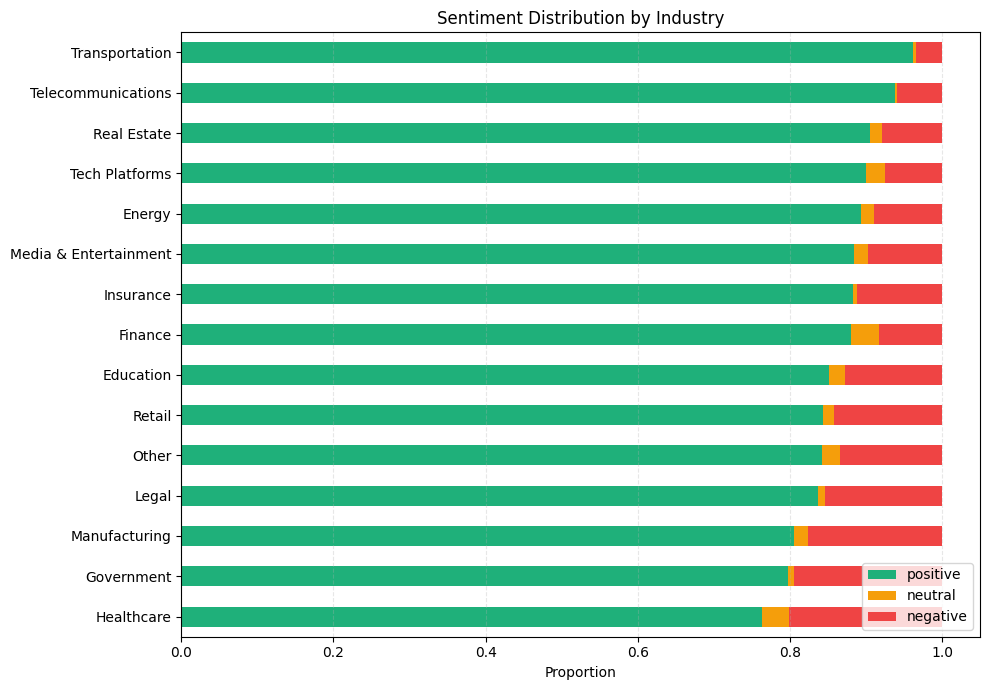

In [114]:
industry_sentiment = (
    df_news_final_project
    .groupby("industry")["sentiment"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

industry_sentiment = industry_sentiment[["positive","neutral","negative"]]
industry_sentiment = industry_sentiment.sort_values(by="positive", ascending=True)
colors = {
    "positive": "#1fb07a",
    "neutral": "#f59e0b",
    "negative": "#ef4444"
}
industry_sentiment.plot(
    kind="barh",
    stacked=True,
    color=[colors[c] for c in industry_sentiment.columns],
    figsize=(10,7)
)

plt.xlabel("Proportion")
plt.ylabel("")
plt.title("Sentiment Distribution by Industry")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [97]:
df_news_final_project.to_parquet(
    "/content/drive/MyDrive/NLP_AI_Impact_Project/data/with_sentiment.parquet"
)